# 05 Results Analysis

This notebook generates:
- **Part 1**: Heatmaps of 9 experiment groups (mean ± std) for Average $R^2$ and per-scope $R^2$.
- **Part 2**: Per-country best model table (55 countries ordered by labeled sample size).

In [1]:
# Part 0) Imports and paths
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("white")

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.exists(os.path.join(project_root, 'results')):
    project_root = os.path.abspath(os.getcwd())

results_dir = os.path.join(project_root, 'results')
data_dir = os.path.join(project_root, 'data')

print('project_root =', project_root)
print('results_dir  =', results_dir)
print('data_dir     =', data_dir)

# Result files (kept files)
cpu_path = os.path.join(results_dir, 'cpu_ab_experiments_full_results.csv')
gpu_path = os.path.join(results_dir, 'gpu_cd_experiments_full_results.csv')
ct_path = os.path.join(results_dir, 'ct_experiments_ct_v3.4_C_CT_all55_seed42_20260207_161832.csv')

print('CPU results:', os.path.exists(cpu_path))
print('GPU results:', os.path.exists(gpu_path))
print('CT results :', os.path.exists(ct_path))

TARGET_COLS = [
    'log_Scope1', 'log_Scope2', 'log_Scope3_upstream',
    'log_Scope3_downLA', 'log_Scope3_prod', 'log_Scope_total'
]
R2_COLS = [f'R2_{c}' for c in TARGET_COLS]


project_root = d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning
results_dir  = d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results
data_dir     = d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\data
CPU results: True
GPU results: True
CT results : True


In [2]:
# Part 0.1) Load and normalize results (9 canonical experiments)

def _map_experiment_code(raw: str) -> str:
    if raw is None:
        return ''
    raw = str(raw)
    mapping = {
        'A': 'A_star',
        'A_star': 'A_star',
        'B': 'B',
        'B_dev': 'B_dev',
        'C': 'C',
        'C_dev': 'C_dev',
        'D': 'D_lora',
        'D_dev': 'D_lora_dev',
        'D_lora': 'D_lora',
        'D_lora_dev': 'D_lora_dev',
        'D_full': 'D_full',
        'D_full_dev': 'D_full_dev',
    }
    # Verbose labels from some runners
    if 'Country_Self_Modeling' in raw:
        return 'A_star'
    if 'Global_Baseline' in raw:
        return 'B'
    if 'Developed_Baseline' in raw:
        return 'B_dev'
    if 'Transfer_Learning' in raw and 'Developed' in raw and 'FTT' not in raw:
        return 'C_dev'
    if 'Transfer_Learning' in raw and 'FTT' not in raw:
        return 'C'
    if 'FTT_LoRA' in raw and 'Developed' in raw:
        return 'D_lora_dev'
    if 'FTT_LoRA' in raw:
        return 'D_lora'
    if 'FTT_Full' in raw and 'Developed' in raw:
        return 'D_full_dev'
    if 'FTT_Full' in raw:
        return 'D_full'
    # Map FTT variants to D_lora/D_lora_dev
    if 'Transfer_Learning_FTT' in raw and 'Developed' in raw:
        return 'D_lora_dev'
    if 'Transfer_Learning_FTT' in raw:
        return 'D_lora'
    # LoRA fallback
    if 'LoRA' in raw and 'Developed' in raw:
        return 'D_lora_dev'
    if 'LoRA' in raw:
        return 'D_lora'
    return mapping.get(raw, raw)


def _ensure_r2_columns(df: pd.DataFrame) -> pd.DataFrame:
    # If per-scope columns are stored as log_Scope*, map to R2_log_* columns
    for tgt in TARGET_COLS:
        if tgt in df.columns:
            df[f'R2_{tgt}'] = df[tgt]

    # If R2_target_0..5 exist, map them to R2_log_* columns
    target_cols = [c for c in df.columns if c.startswith('R2_target_')]
    if target_cols and not all(c in df.columns for c in R2_COLS):
        idx_map = {
            0: 'log_Scope1',
            1: 'log_Scope2',
            2: 'log_Scope3_upstream',
            3: 'log_Scope3_prod',
            4: 'log_Scope3_downLA',
            5: 'log_Scope_total'
        }
        for i, tgt in idx_map.items():
            col = f'R2_target_{i}'
            if col in df.columns:
                df[f'R2_{tgt}'] = df[col]

    # Map alternative R2 column names to standard ones (case-insensitive)
    lower_cols = {c.lower(): c for c in df.columns}
    for tgt in TARGET_COLS:
        std_col = f'R2_{tgt}'
        if std_col in df.columns:
            continue
        base = tgt.replace('log_', '')
        candidates = [
            f'R2_{tgt}',
            f'R2_{base}',
            f'R2_{base.lower()}',
            f'R2_{tgt.lower()}'
        ]
        found = None
        for cand in candidates:
            key = cand.lower()
            if key in lower_cols:
                found = lower_cols[key]
                break
        if found:
            df[std_col] = df[found]

    # Ensure all standard R2 columns exist
    for tgt in TARGET_COLS:
        col = f'R2_{tgt}'
        if col not in df.columns:
            df[col] = np.nan

    # If R2_Average missing, compute from available scope columns
    if 'R2_Average' not in df.columns:
        available = [c for c in R2_COLS if c in df.columns]
        if available:
            df['R2_Average'] = df[available].mean(axis=1, skipna=True)

    # Coerce to numeric
    numeric_cols = ['R2_Average'] + [c for c in R2_COLS if c in df.columns]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df


def _load_results(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        return pd.DataFrame()
    df = pd.read_csv(path)
    return df

cpu_df = _load_results(cpu_path)
gpu_df = _load_results(gpu_path)

for df in [cpu_df, gpu_df]:
    if df.empty:
        continue
    exp_col = 'experiment_code' if 'experiment_code' in df.columns else 'experiment_type'
    df['experiment_code'] = df[exp_col].apply(_map_experiment_code)
    df = _ensure_r2_columns(df)

# Combine 9 canonical experiments
combined = pd.concat([cpu_df, gpu_df], ignore_index=True)
canonical_order = ['A_star','B','B_dev','C','C_dev','D_lora','D_lora_dev','D_full','D_full_dev']
combined = combined[combined['experiment_code'].isin(canonical_order)].copy()

print('Combined rows:', len(combined))
print('Experiments:', combined['experiment_code'].value_counts().to_dict())
print('Columns:', [c for c in ['country','experiment_code','R2_Average'] + R2_COLS if c in combined.columns])


Combined rows: 495
Experiments: {'A_star': 55, 'B': 55, 'B_dev': 55, 'C': 55, 'C_dev': 55, 'D_lora': 55, 'D_lora_dev': 55, 'D_full': 55, 'D_full_dev': 55}
Columns: ['country', 'experiment_code', 'R2_Average', 'R2_log_Scope1', 'R2_log_Scope2', 'R2_log_Scope3_upstream', 'R2_log_Scope3_downLA', 'R2_log_Scope3_prod', 'R2_log_Scope_total']


In [3]:
# Part 0.2) Build country order by labeled sample size
processed_hdf5_path = os.path.join(data_dir, 'processed_feature_data.h5')

if os.path.exists(processed_hdf5_path):
    df_full = pd.read_hdf(processed_hdf5_path, key='processed_features')
    valid_loc = (
        df_full['loc'].notna() & (df_full['loc'] != '') & (df_full['loc'].astype(str).str.strip() != '')
        & (df_full['loc'].astype(str).str.len() >= 2)
        & (df_full['loc'].astype(str).str.isalpha())
        & (df_full['loc'].astype(str).str.len() <= 10)
    )
    df_full = df_full[valid_loc].copy()
    df_labeled = df_full[df_full[TARGET_COLS].notnull().all(axis=1)].copy()
    country_order = df_labeled['loc'].value_counts().index.tolist()
    country_counts = df_labeled['loc'].value_counts().to_dict()
    print('Eligible countries (>=50) total:', sum(1 for c in country_order if country_counts.get(c, 0) >= 50))
else:
    df_labeled = pd.DataFrame()
    country_order = sorted(combined['country'].unique())
    country_counts = {c: np.nan for c in country_order}
    print('processed_feature_data.h5 not found, fallback to alphabetical country order')


Eligible countries (>=50) total: 55


Saved heatmap: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\heatmap_9_experiments_mean_std.png


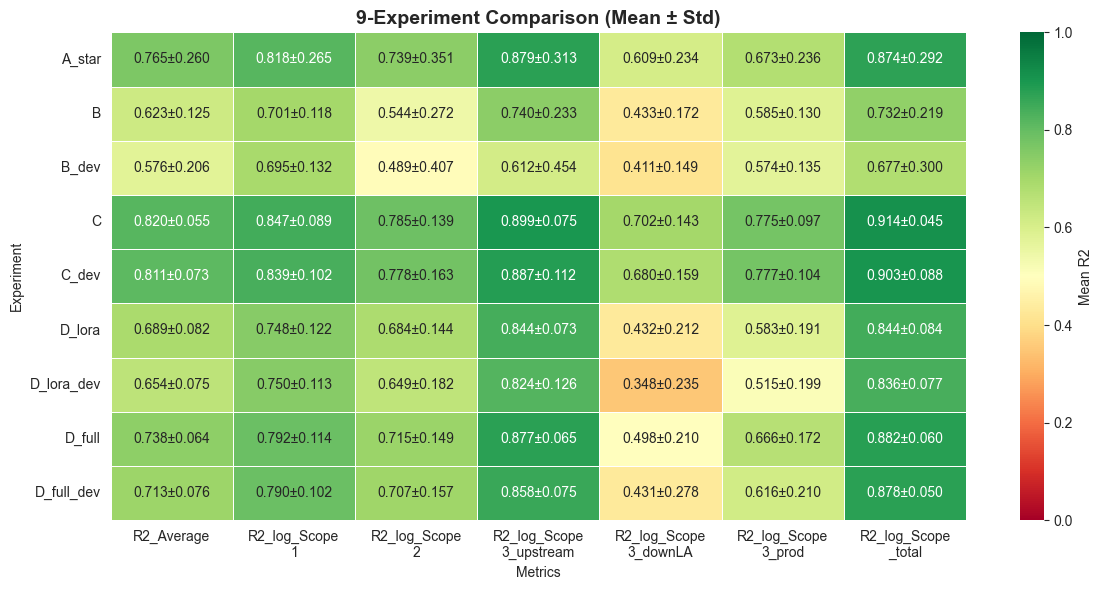

In [4]:
# Part 1) Heatmap of 9 experiments: mean ± std for Average R2 and per-scope R2
metrics = ['R2_Average'] + [c for c in R2_COLS if c in combined.columns]

summary = combined.groupby('experiment_code')[metrics].agg(['mean', 'std'])
summary = summary.reindex(canonical_order)

mean_df = summary.xs('mean', level=1, axis=1)
std_df = summary.xs('std', level=1, axis=1)

# Build annotation strings "mean±std"
annot = pd.DataFrame(index=mean_df.index, columns=mean_df.columns, dtype=object)
for col in mean_df.columns:
    mean_col = mean_df[col]
    std_col = std_df[col]
    annot[col] = [f"{m:.3f}±{s:.3f}" if pd.notna(m) else 'N/A' for m, s in zip(mean_col, std_col)]

plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    mean_df,
    annot=annot,
    fmt='',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Mean R2'}
)
plt.title('9-Experiment Comparison (Mean ± Std)', fontsize=14, fontweight='bold')
plt.xlabel('Metrics')
plt.ylabel('Experiment')
wrapped_metrics = [
    "\n".join(textwrap.wrap(metric, width=12)) or metric
    for metric in mean_df.columns
]
ax.set_xticklabels(wrapped_metrics, rotation=0, ha='center')
plt.tight_layout()

# Save figure
heatmap_path = os.path.join(results_dir, 'heatmap_9_experiments_mean_std.png')
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
print('Saved heatmap:', heatmap_path)

plt.show()

Saved table image: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\best_model_per_country_table.png


,country,labeled_samples,best_experiment,R2_Average,R2_log_Scope1,R2_log_Scope2,R2_log_Scope3_upstream,R2_log_Scope3_downLA,R2_log_Scope3_prod,R2_log_Scope_total
0,USA,15514,A_star,0.905000,0.940000,0.946000,0.982000,0.734000,0.844000,0.981000
1,CHN,13988,A_star,0.882000,0.885000,0.871000,0.966000,0.784000,0.837000,0.949000
2,JPN,11099,A_star,0.876000,0.899000,0.915000,0.978000,0.695000,0.798000,0.972000
3,KOR,5476,A_star,0.877000,0.908000,0.946000,0.977000,0.682000,0.777000,0.973000
4,TWN,4315,A_star,0.832000,0.834000,0.868000,0.972000,0.672000,0.705000,0.942000
5,IND,3618,A_star,0.846000,0.885000,0.807000,0.949000,0.698000,0.799000,0.936000
6,HKG,2678,A_star,0.877000,0.871000,0.900000,0.945000,0.780000,0.818000,0.948000
7,GBR,2326,A_star,0.826000,0.885000,0.892000,0.968000,0.571000,0.681000,0.961000
8,AUS,2220,A_star,0.847000,0.837000,0.861000,0.960000,0.786000,0.703000,0.933000
9,CAN,2115,A_star,0.866000,0.908000,0.850000,0.967000,0.758000,0.762000,0.950000


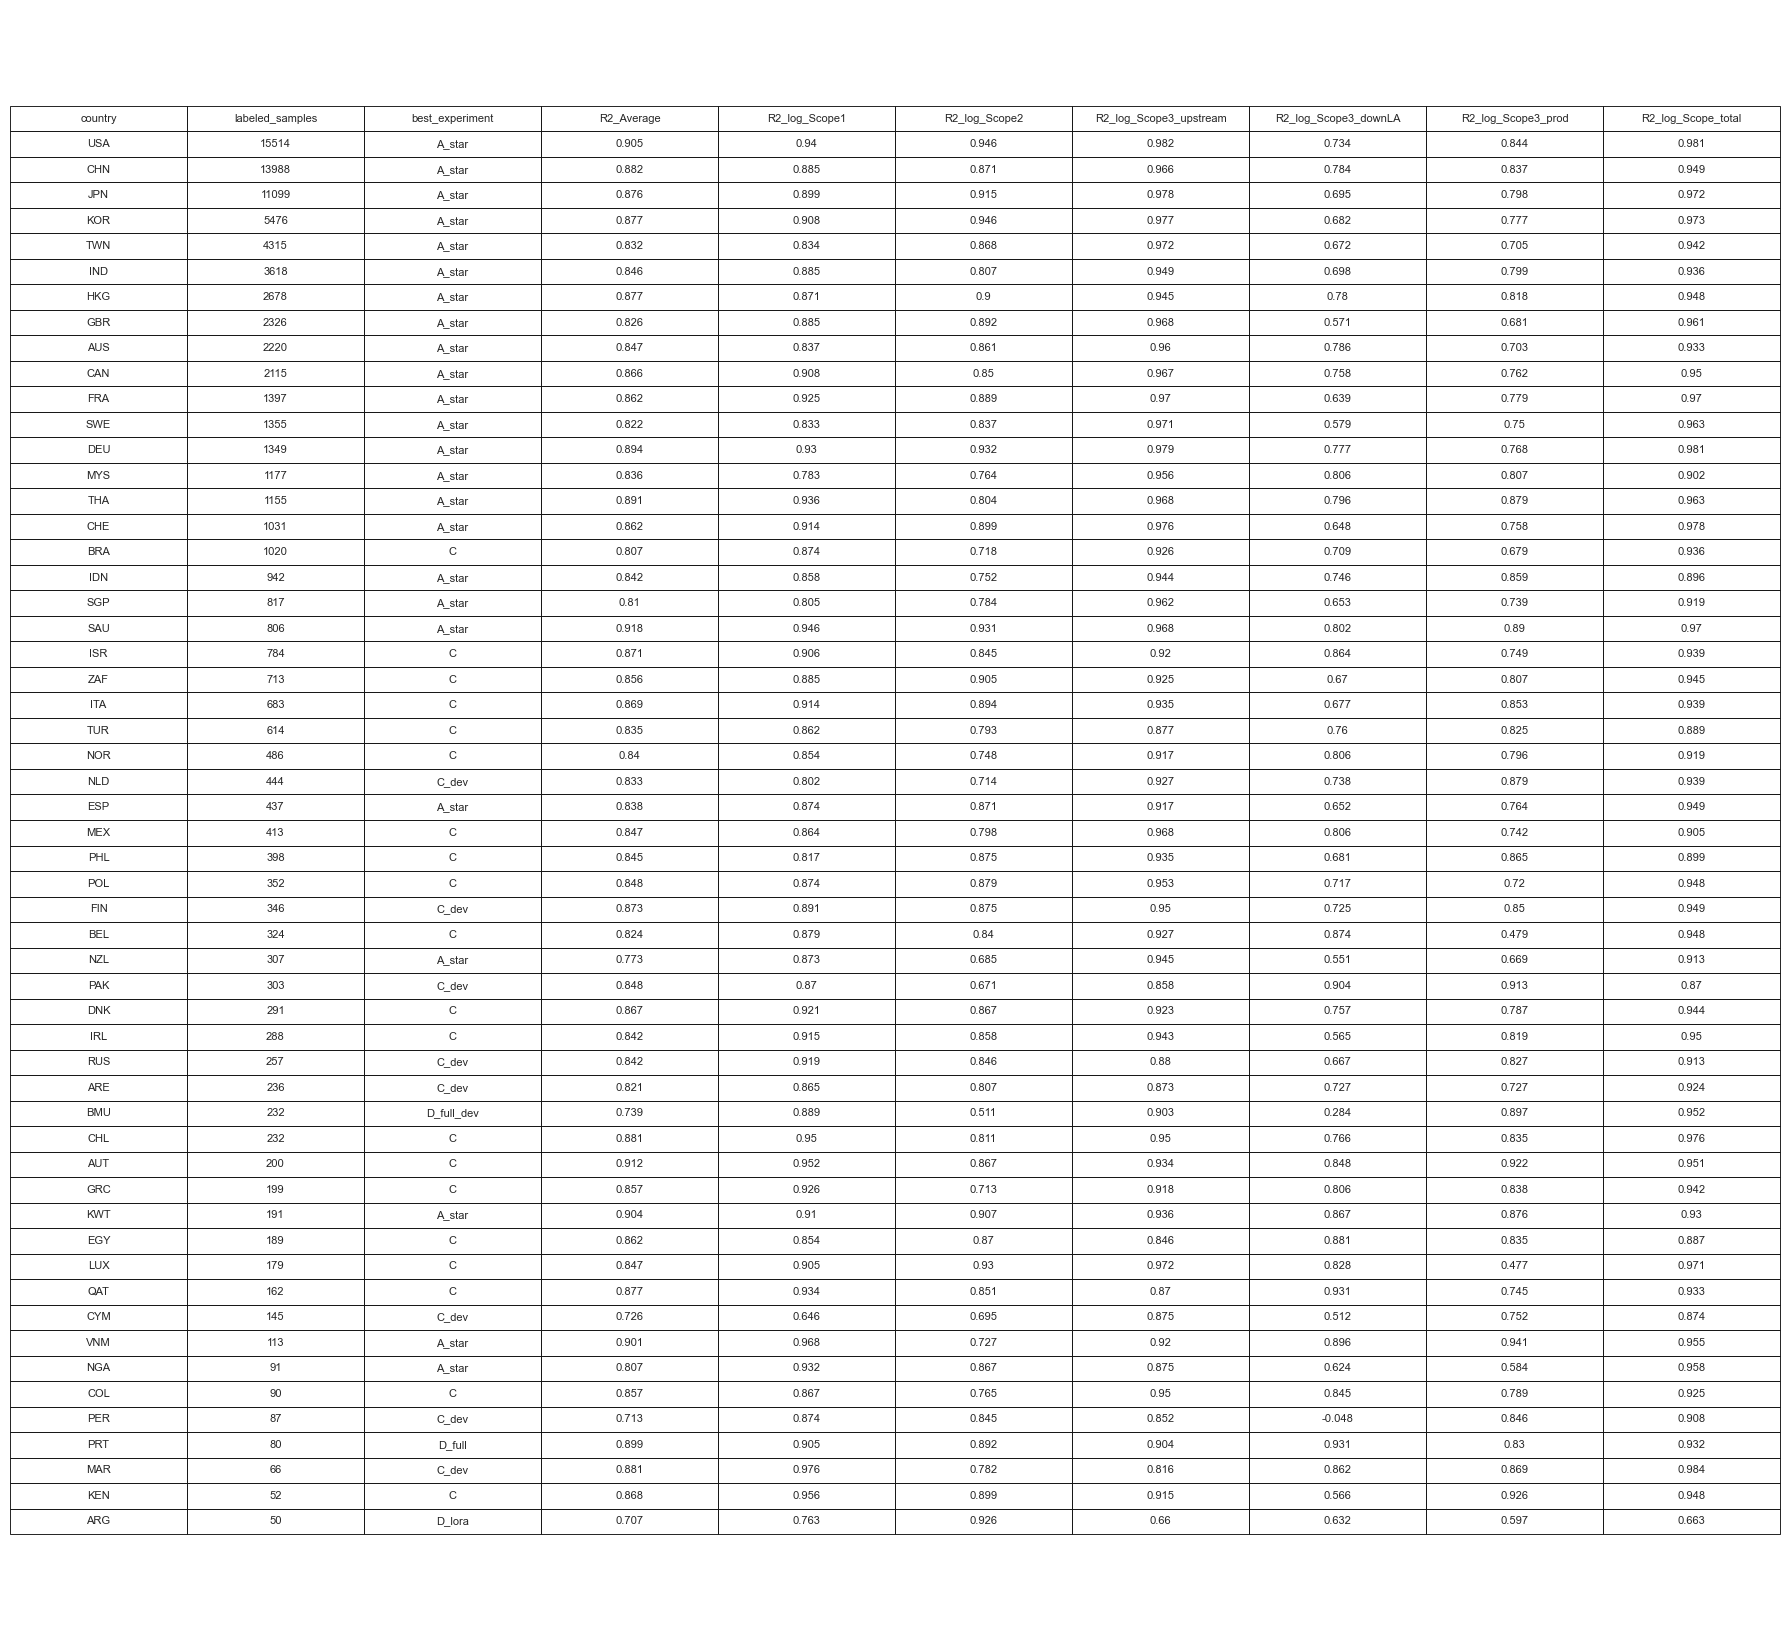

In [5]:
# Part 2) Best model per country (ordered by labeled sample size)

# Filter to countries with >= 50 labeled samples (Emi-Bench rule)
eligible_countries = [c for c in country_order if country_counts.get(c, 0) >= 50]

# Ensure we only use the 9 canonical experiments for comparison
canonical = combined[combined['experiment_code'].isin(canonical_order)].copy()

# Select best experiment per country by Average R2
best_rows = []
for country in eligible_countries:
    sub = canonical[canonical['country'] == country]
    if sub.empty:
        continue
    best_idx = sub['R2_Average'].idxmax()
    best = sub.loc[best_idx]
    row = {
        'country': country,
        'labeled_samples': country_counts.get(country, np.nan),
        'best_experiment': best.get('experiment_code', ''),
        'R2_Average': best.get('R2_Average', np.nan),
    }
    for col in R2_COLS:
        if col in canonical.columns:
            row[col] = best.get(col, np.nan)
    best_rows.append(row)

best_df = pd.DataFrame(best_rows)

# Order by labeled samples (descending)
best_df = best_df.sort_values(by='labeled_samples', ascending=False)

# Round for display
display_df = best_df.copy()
metric_cols = ['R2_Average'] + [c for c in R2_COLS if c in display_df.columns]
display_df[metric_cols] = display_df[metric_cols].round(3)

# Line-table style (gridlines)
styles = [
    {'selector': 'th', 'props': [('border', '1px solid black'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid black'), ('text-align', 'center')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]}
]

styled = display_df.style.set_table_styles(styles).set_caption(
    'Best model per country (ordered by labeled sample size)'
)

# Save table as image (matplotlib)
fig, ax = plt.subplots(figsize=(18, max(6, 0.3 * len(display_df))))
ax.axis('off')

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.2)

for key, cell in table.get_celld().items():
    cell.set_linewidth(0.6)

plt.tight_layout()

table_path = os.path.join(results_dir, 'best_model_per_country_table.png')
plt.savefig(table_path, dpi=300, bbox_inches='tight')
print('Saved table image:', table_path)

styled

In [6]:
# Part 3) Labeled sample size characteristics for best-model countries
target_experiments = ['A_star', 'C', 'C_dev', 'D_lora', 'D_full', 'D_full_dev']
best_sub = best_df[best_df['best_experiment'].isin(target_experiments)].copy()

label_stats = (
    best_sub.groupby('best_experiment')['labeled_samples']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reindex(target_experiments)
    .round(2)
 )
print('Labeled sample size stats by best experiment:')
print(label_stats)

# Feature-based characteristics (use feature columns from results if present; otherwise fallback to processed data)
exclude_cols = set(['country', 'experiment_code', 'experiment_type', 'best_experiment', 'labeled_samples'])
exclude_cols.update(R2_COLS)
exclude_cols.add('R2_Average')

numeric_cols = [c for c in combined.columns if pd.api.types.is_numeric_dtype(combined[c])]
feature_cols = [c for c in numeric_cols if c not in exclude_cols and not c.startswith('R2_')]

country_feature_mean = None
if feature_cols:
    country_feature_mean = combined.groupby('country')[feature_cols].mean(numeric_only=True)
elif 'df_full' in globals() and not df_full.empty:
    base_cols = [c for c in df_full.columns if c not in (['loc'] + TARGET_COLS)]
    numeric_base = [c for c in base_cols if pd.api.types.is_numeric_dtype(df_full[c])]
    if numeric_base:
        country_feature_mean = df_full.groupby('loc')[numeric_base].mean(numeric_only=True)

if country_feature_mean is None or country_feature_mean.empty:
    print('No numeric feature columns found for feature-based analysis.')
else:
    overall_mean = country_feature_mean.mean(numeric_only=True)
    overall_std = country_feature_mean.std(numeric_only=True).replace(0, np.nan)

    summary_rows = []
    for exp in target_experiments:
        countries = best_sub.loc[best_sub['best_experiment'] == exp, 'country']
        if countries.empty:
            continue
        exp_feature_mean = country_feature_mean.loc[countries].mean(numeric_only=True)
        z_scores = ((exp_feature_mean - overall_mean) / overall_std).dropna()

        top_pos = z_scores.sort_values(ascending=False).head(3)
        top_neg = z_scores.sort_values().head(3)

        summary_rows.append({
            'experiment': exp,
            'top_high_features (z)': '; '.join([f"{k}:{v:.2f}" for k, v in top_pos.items()]),
            'top_low_features (z)': '; '.join([f"{k}:{v:.2f}" for k, v in top_neg.items()]),
        })

    exp_table = pd.DataFrame(summary_rows)
    print('Top feature deviations vs overall mean (z-score):')
    print(exp_table)

label_stats
exp_table if 'exp_table' in locals() else label_stats

Labeled sample size stats by best experiment:
                 count     mean  median      std  min    max
best_experiment                                             
A_star              24  3104.88  1352.0  4292.49   91  15514
C                   20   383.45   307.5   258.15   52   1020
C_dev                8   235.50   246.5   130.75   66    444
D_lora               1    50.00    50.0      NaN   50     50
D_full               1    80.00    80.0      NaN   80     80
D_full_dev           1   232.00   232.0      NaN  232    232
Top feature deviations vs overall mean (z-score):
   experiment                              top_high_features (z)  \
0      A_star  finetune_samples:0.50; valid_training_samples:...   
1           C  log_Scope1:0.42; training_samples:0.36; MAE_Av...   
2       C_dev  log_Scope3_prod:0.64; training_samples:0.39; l...   
3      D_lora  MAE_Average:2.69; RMSE_Average:1.09; training_...   
4      D_full  log_Scope1:1.37; log_Scope2:0.99; log_Scope_to...   
5  D_ful

,experiment,top_high_features (z),top_low_features (z)
0,A_star,finetune_samples:0.50; valid_training_samples:...,training_samples:-0.48; log_Scope1:-0.31; MAE_...
1,C,log_Scope1:0.42; training_samples:0.36; MAE_Av...,log_Scope3_prod:-0.42; finetune_samples:-0.37;...
2,C_dev,log_Scope3_prod:0.64; training_samples:0.39; l...,valid_training_samples:-0.41; finetune_samples...
3,D_lora,MAE_Average:2.69; RMSE_Average:1.09; training_...,log_Scope3_upstream:-3.82; log_Scope_total:-3....
4,D_full,log_Scope1:1.37; log_Scope2:0.99; log_Scope_to...,data_efficiency:-1.15; RMSE_Average:-1.04; MAE...
5,D_full_dev,RMSE_Average:1.01; log_Scope1:1.01; log_Scope3...,log_Scope2:-1.29; data_efficiency:-0.75; log_S...


Saved stats CSV: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\labeled_sample_size_stats_by_best_experiment.csv
Saved stats image: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\labeled_sample_size_stats_by_best_experiment.png


,count,mean,median,std,min,max
best_experiment,,,,,,
A_star,24,3104.88,1352.0,4292.49,91,15514
C,20,383.45,307.5,258.15,52,1020
C_dev,8,235.50,246.5,130.75,66,444
D_lora,1,50.00,50.0,NaN,50,50
D_full,1,80.00,80.0,NaN,80,80
D_full_dev,1,232.00,232.0,NaN,232,232


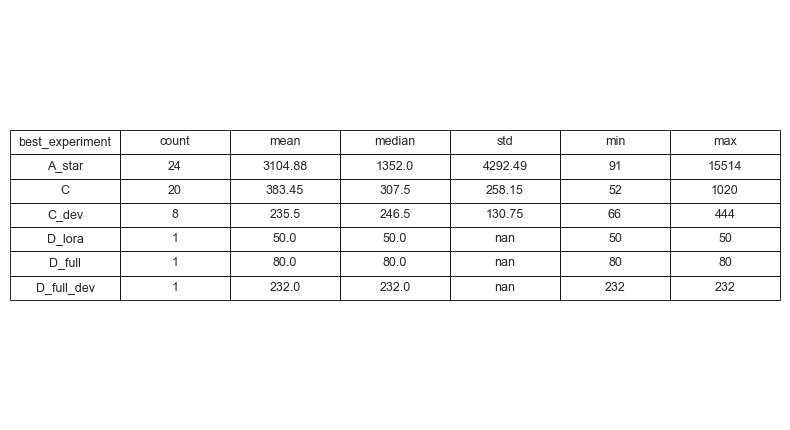

In [7]:
# Part 4) Export labeled sample size stats table
label_stats_out = label_stats.copy()
label_stats_out.index.name = 'best_experiment'

# Save CSV
label_stats_csv = os.path.join(results_dir, 'labeled_sample_size_stats_by_best_experiment.csv')
label_stats_out.to_csv(label_stats_csv)
print('Saved stats CSV:', label_stats_csv)

# Save as image (matplotlib table)
fig, ax = plt.subplots(figsize=(8, 2 + 0.4 * len(label_stats_out)))
ax.axis('off')

table = ax.table(
    cellText=label_stats_out.reset_index().values,
    colLabels=label_stats_out.reset_index().columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.2)
for key, cell in table.get_celld().items():
    cell.set_linewidth(0.6)

plt.tight_layout()
label_stats_png = os.path.join(results_dir, 'labeled_sample_size_stats_by_best_experiment.png')
plt.savefig(label_stats_png, dpi=300, bbox_inches='tight')
print('Saved stats image:', label_stats_png)

label_stats_out

Saved CT per-country CSV: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\ct_country_r2_table.csv
Saved CT per-country table image: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\ct_country_r2_table.png


,country,labeled_samples,R2_Average,R2_log_Scope1,R2_log_Scope2,R2_log_Scope3_upstream,R2_log_Scope3_downLA,R2_log_Scope3_prod,R2_log_Scope_total
8,USA,15514,0.7493,0.8637,0.8627,0.9409,0.5971,0.2886,0.9429
9,CHN,13988,0.6701,0.7420,0.7406,0.8952,0.5459,0.2044,0.8926
17,JPN,11099,0.7128,0.8062,0.8370,0.9112,0.6006,0.1981,0.9233
28,KOR,5476,0.7378,0.8195,0.8751,0.9108,0.6074,0.2944,0.9195
41,TWN,4315,0.6876,0.7045,0.7972,0.9110,0.5768,0.2294,0.9066
42,IND,3618,0.6116,0.7032,0.5152,0.8649,0.5120,0.2431,0.8312
7,HKG,2678,0.7410,0.7169,0.8075,0.8737,0.6840,0.4732,0.8905
29,GBR,2326,0.6616,0.7529,0.7412,0.8853,0.4205,0.2955,0.8740
30,AUS,2220,0.7165,0.7749,0.7639,0.8783,0.5799,0.4294,0.8729
43,CAN,2115,0.7148,0.7935,0.7453,0.9087,0.4821,0.4700,0.8891


Saved CT group means CSV: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\ct_group_r2_means.csv
Saved CT group means image: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\ct_group_r2_table.png


C:\Users\江亦晗\AppData\Local\Temp\ipykernel_12064\815820930.py:89: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = ct_for_group.groupby('sample_group')[group_metrics].mean().reindex(['High','Medium','Low'])


,R2_Average,R2_log_Scope1,R2_log_Scope2,R2_log_Scope3_upstream,R2_log_Scope3_downLA,R2_log_Scope3_prod,R2_log_Scope_total
sample_group,,,,,,,
High,0.6884,0.7563,0.7302,0.8816,0.5612,0.3241,0.8771
Medium,0.6194,0.7078,0.6356,0.7732,0.4874,0.3453,0.7668
Low,0.4764,0.7380,0.5003,0.4588,0.1676,0.3523,0.6415


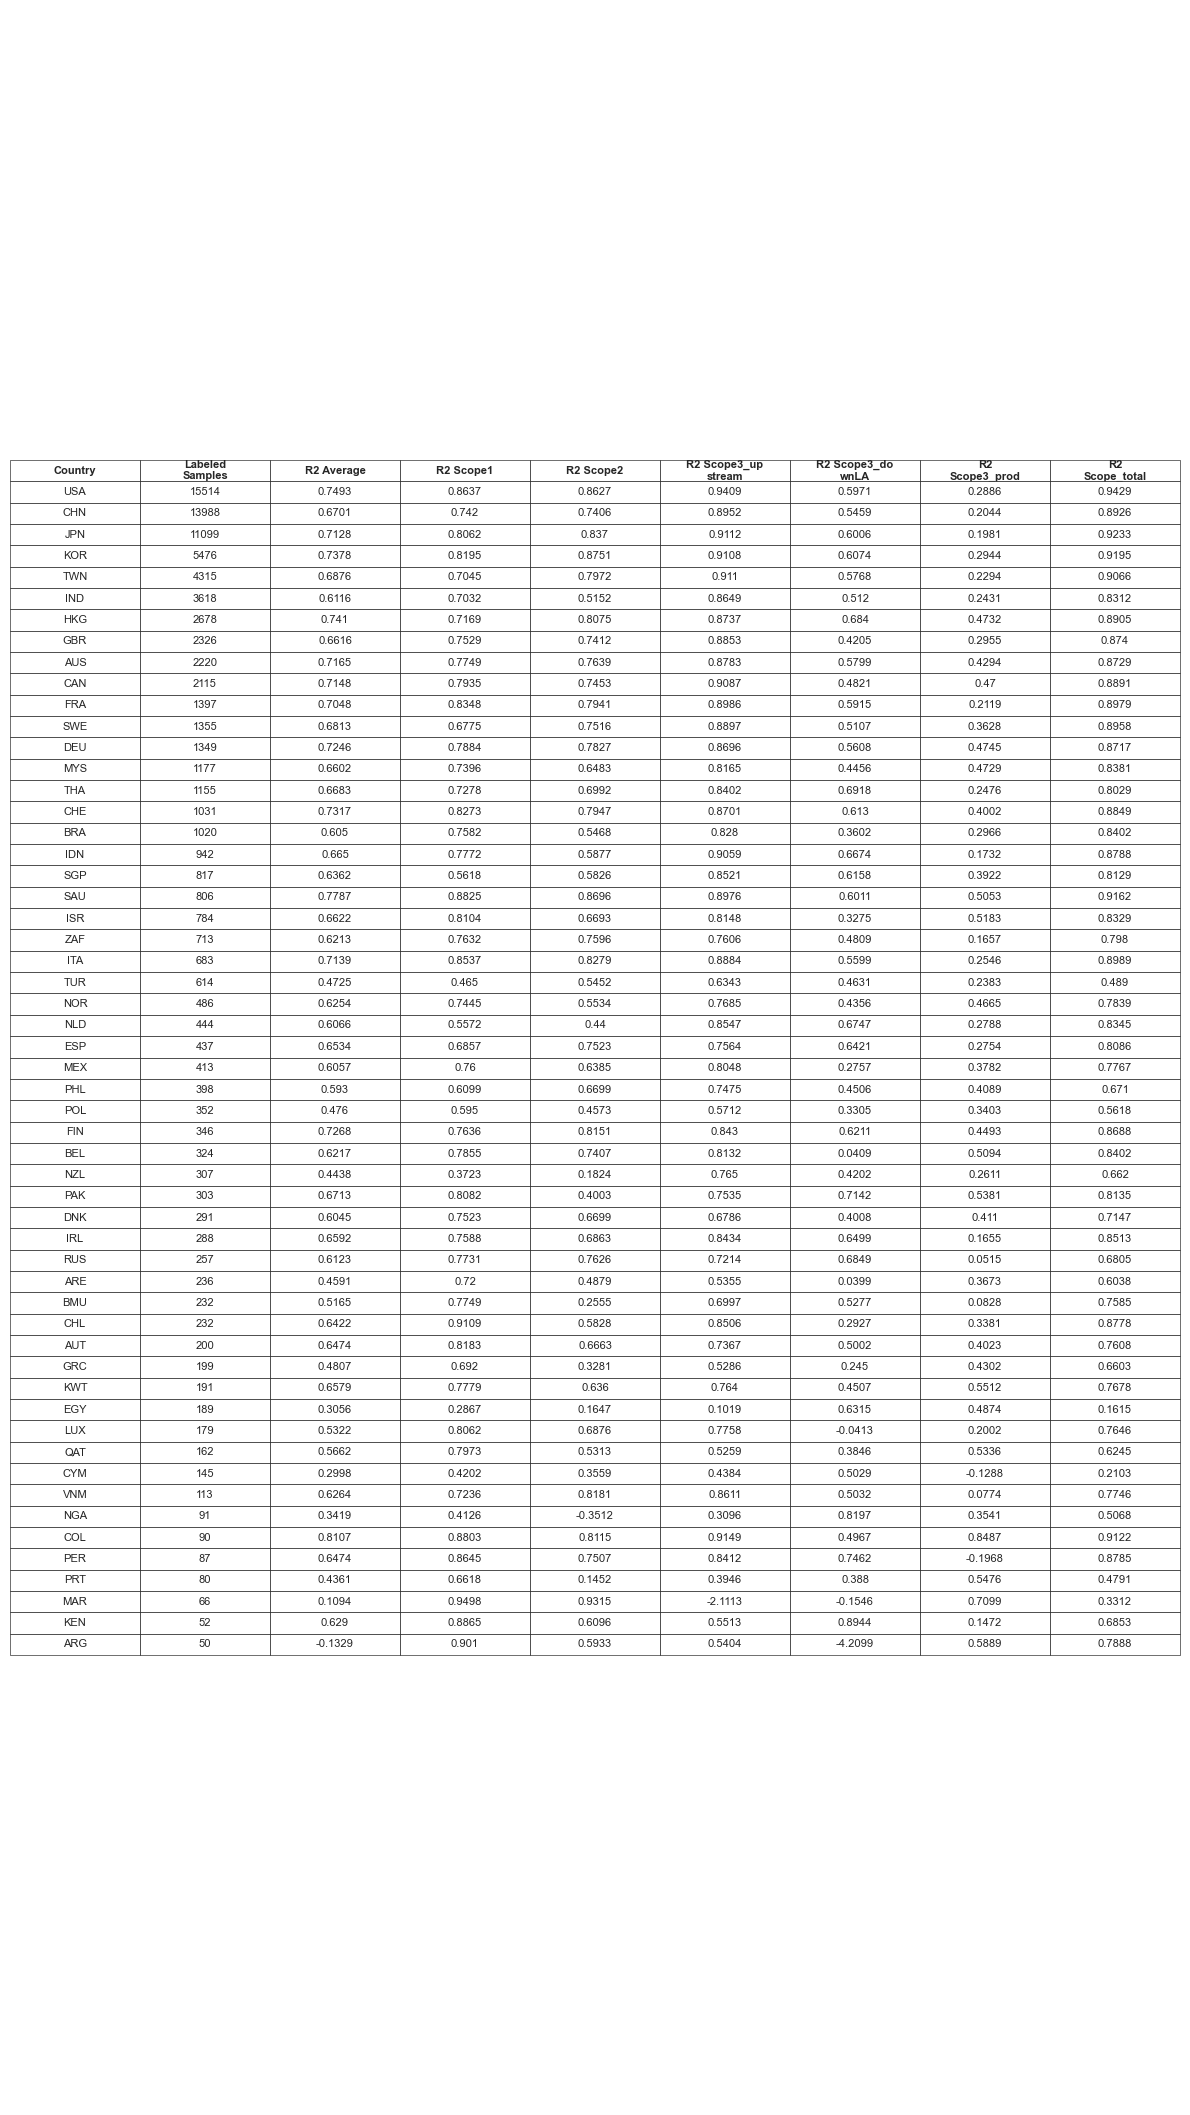

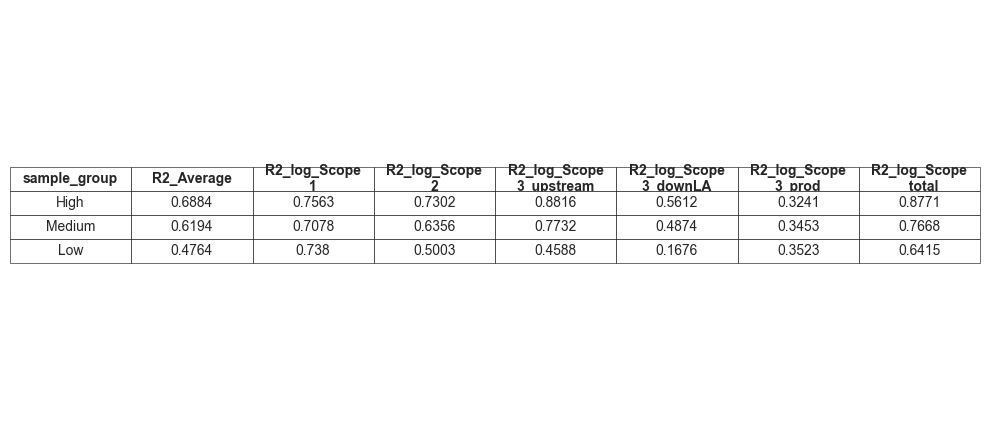

In [14]:
# Part 5) CT per-country R2 table (with labeled sample size) and grouped summaries
ct_df = _load_results(ct_path)
if ct_df.empty:
    print('CT results file not found or empty:', ct_path)
else:
    # Normalize columns and map experiment codes if needed
    if 'experiment_code' not in ct_df.columns and 'experiment_type' in ct_df.columns:
        ct_df['experiment_code'] = ct_df['experiment_type'].apply(_map_experiment_code)
    ct_df = _ensure_r2_columns(ct_df)
    # Identify CT rows: use experiment_code or experiment_type
    is_ct = pd.Series(False, index=ct_df.index)
    if 'experiment_code' in ct_df.columns:
        is_ct = is_ct | (ct_df['experiment_code'].astype(str).str.contains('C_CT', na=False) | ct_df['experiment_code'].astype(str).str.contains('C', na=False))
    if 'experiment_type' in ct_df.columns:
        is_ct = is_ct | ct_df['experiment_type'].astype(str).str.contains('Cross_Time_Contrastive_Learning', na=False)
    ct_rows = ct_df[is_ct].copy()
    if ct_rows.empty:
        print('No CT rows found in CT results file')
    else:
        # Add labeled_samples from country_counts if available, fallback to target_train_samples or n_train/n_total
        def get_label_count(row):
            c = row.get('country')
            if c in country_counts and not pd.isna(country_counts.get(c)):
                return country_counts.get(c)
            for cand in ['target_train_samples','target_train','n_train','n_total','target_samples'] :
                if cand in row and pd.notna(row.get(cand)):
                    return row.get(cand)
            return np.nan
        ct_rows['labeled_samples'] = ct_rows.apply(get_label_count, axis=1)
        # Select display columns
        display_cols = ['country','labeled_samples','R2_Average'] + [c for c in R2_COLS if c in ct_rows.columns]
        ct_table = ct_rows[display_cols].copy()
        # Round R2 numeric columns to 4 decimals
        r2_cols_in_table = [c for c in ct_table.columns if c not in ['country','labeled_samples']]
        for c in r2_cols_in_table:
            ct_table[c] = pd.to_numeric(ct_table[c], errors='coerce').round(4)
        ct_table_sorted = ct_table.sort_values(by='labeled_samples', ascending=False, na_position='last')
        # Save CSV
        ct_table_csv = os.path.join(results_dir, 'ct_country_r2_table.csv')
        ct_table_sorted.to_csv(ct_table_csv, index=False)
        print('Saved CT per-country CSV:', ct_table_csv)
        # Build readable header labels and wrap if long
        header_map = {'country': 'Country', 'labeled_samples': 'Labeled Samples', 'R2_Average': 'R2 Average'}
        for tgt in TARGET_COLS:
            std = f'R2_{tgt}'
            short = std.replace('R2_log_', 'R2 ').replace('R2_', 'R2 ')
            header_map[std] = short
        header_labels = ["\n".join(textwrap.wrap(header_map.get(c, c), width=12)) for c in ct_table_sorted.columns]
        # Save as image (adjust size)
        fig_width = 12
        fig_height = max(3, min(0.35 * len(ct_table_sorted) + 2, 60))
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        ax.axis('off')
        tbl = ax.table(
            cellText=ct_table_sorted.values,
            colLabels=header_labels,
            cellLoc='center',
            loc='center'
        )
        # Bold header row
        ncols = len(ct_table_sorted.columns)
        for j in range(ncols):
            cell = tbl[0, j]
            cell.set_text_props(weight='bold')
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(8)
        tbl.scale(1, 1.0)
        for key, cell in tbl.get_celld().items():
            cell.set_linewidth(0.4)
        plt.tight_layout()
        ct_table_png = os.path.join(results_dir, 'ct_country_r2_table.png')
        plt.savefig(ct_table_png, dpi=300, bbox_inches='tight')
        print('Saved CT per-country table image:', ct_table_png)
        display(ct_table_sorted)
        # ---- Group into tertiles by labeled_samples ----
        ct_for_group = ct_table_sorted.dropna(subset=['labeled_samples']).copy()
        if ct_for_group.empty:
            print('No countries with labeled_samples available for grouping')
        else:
            # create tertile bins; if fewer unique values, use quantiles with duplicates handled
            try:
                ct_for_group['sample_group'] = pd.qcut(ct_for_group['labeled_samples'], q=3, labels=['Low','Medium','High'])
            except Exception:
                # fallback to manual bins by percentiles
                edges = ct_for_group['labeled_samples'].quantile([0, 1/3, 2/3, 1.0]).values
                ct_for_group['sample_group'] = pd.cut(ct_for_group['labeled_samples'], bins=edges, labels=['Low','Medium','High'], include_lowest=True)
            # Compute group means for R2 metrics
            group_metrics = ['R2_Average'] + [c for c in R2_COLS if c in ct_for_group.columns]
            group_means = ct_for_group.groupby('sample_group')[group_metrics].mean().reindex(['High','Medium','Low'])
            group_means = group_means.round(4)
            # Save CSV & PNG for group means
            group_csv = os.path.join(results_dir, 'ct_group_r2_means.csv')
            group_means.to_csv(group_csv)
            print('Saved CT group means CSV:', group_csv)
            # Save PNG table (wrap headers)
            gm = group_means.reset_index()
            gm_cols = gm.columns.tolist()
            gm_header_labels = ["\n".join(textwrap.wrap(str(c), width=12)) for c in gm_cols]
            fig, ax = plt.subplots(figsize=(10, 2 + 0.8 * len(group_means)))
            ax.axis('off')
            tbl2 = ax.table(
                cellText=gm.values,
                colLabels=gm_header_labels,
                cellLoc='center',
                loc='center',
            )
            # Bold header row
            for j in range(len(gm_cols)):
                cell = tbl2[0, j]
                cell.set_text_props(weight='bold')
            tbl2.auto_set_font_size(False)
            tbl2.set_fontsize(10)
            tbl2.scale(1, 1.2)
            for key, cell in tbl2.get_celld().items():
                cell.set_linewidth(0.4)
            plt.tight_layout()
            group_png = os.path.join(results_dir, 'ct_group_r2_table.png')
            plt.savefig(group_png, dpi=300, bbox_inches='tight')
            print('Saved CT group means image:', group_png)
            display(group_means)

Saved CT vs A raw CSV: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\ct_vs_a_raw_values.csv


C:\Users\江亦晗\AppData\Local\Temp\ipykernel_12064\1773966860.py:71: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = display_df.style.applymap(highlight_ct_better, subset=metrics).set_table_styles([


Saved CT vs A comparison table image: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\ct_vs_a_comparison_table.png


,country,labeled_samples,R2_Average,R2_log_Scope1,R2_log_Scope2,R2_log_Scope3_upstream,R2_log_Scope3_downLA,R2_log_Scope3_prod,R2_log_Scope_total
0,USA,15514,0.9047/0.7493,0.9403/0.8637,0.9459/0.8627,0.9825/0.9409,0.7339/0.5971,0.8441/0.2886,0.9812/0.9429
8,CHN,13988,0.8821/0.6701,0.8854/0.7420,0.8711/0.7406,0.9655/0.8952,0.7844/0.5459,0.8373/0.2044,0.9488/0.8926
6,JPN,11099,0.8764/0.7128,0.8992/0.8062,0.9153/0.8370,0.9782/0.9112,0.6951/0.6006,0.7984/0.1981,0.9722/0.9233
34,KOR,5476,0.8773/0.7378,0.9084/0.8195,0.9462/0.8751,0.9767/0.9108,0.6822/0.6074,0.7773/0.2944,0.9729/0.9195
30,TWN,4315,0.8323/0.6876,0.8338/0.7045,0.8682/0.7972,0.9725/0.9110,0.6721/0.5768,0.7050/0.2294,0.9422/0.9066
32,IND,3618,0.8457/0.6116,0.8854/0.7032,0.8066/0.5152,0.9486/0.8649,0.6982/0.5120,0.7992/0.2431,0.9361/0.8312
20,HKG,2678,0.8772/0.7410,0.8707/0.7169,0.9002/0.8075,0.9455/0.8737,0.7798/0.6840,0.8184/0.4732,0.9485/0.8905
5,GBR,2326,0.8265/0.6616,0.8853/0.7529,0.8921/0.7412,0.9684/0.8853,0.5706/0.4205,0.6811/0.2955,0.9614/0.8740
14,AUS,2220,0.8468/0.7165,0.8367/0.7749,0.8610/0.7639,0.9598/0.8783,0.7862/0.5799,0.7034/0.4294,0.9334/0.8729
1,CAN,2115,0.8660/0.7148,0.9084/0.7935,0.8495/0.7453,0.9673/0.9087,0.7580/0.4821,0.7623/0.4700,0.9503/0.8891


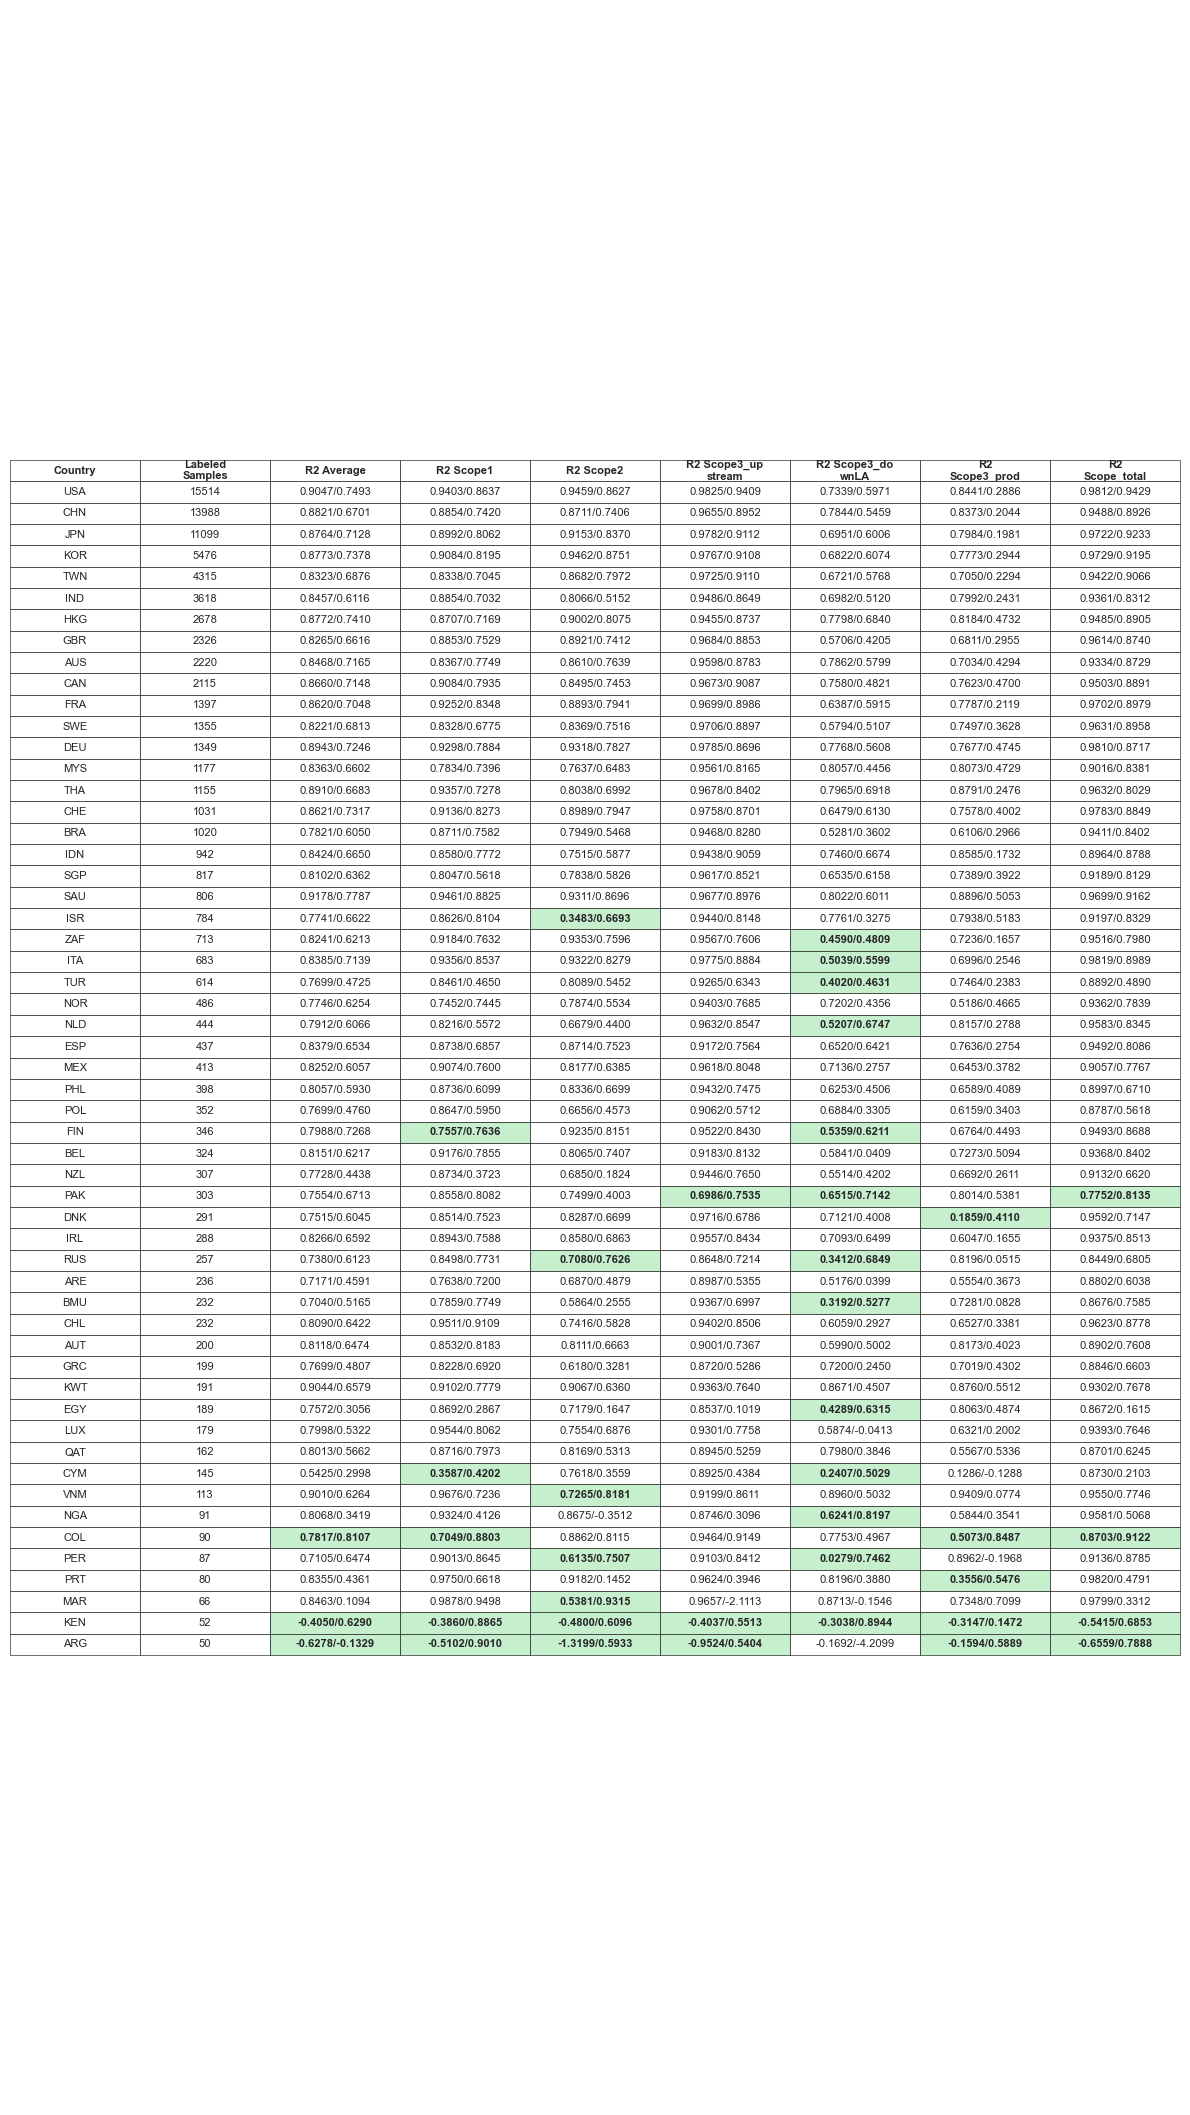

In [15]:
# Part 6) CT vs A comparison table (A/CT) with highlighting
metrics = ['R2_Average'] + [c for c in R2_COLS if c in ct_rows.columns]

# Build A and CT tables
a_rows = combined[combined['experiment_code'] == 'A_star'].copy()
ct_rows_comp = ct_rows.copy()

# Ensure R2 columns are numeric
for col in metrics:
    if col in a_rows.columns:
        a_rows[col] = pd.to_numeric(a_rows[col], errors='coerce')
    if col in ct_rows_comp.columns:
        ct_rows_comp[col] = pd.to_numeric(ct_rows_comp[col], errors='coerce')

# Labeled samples
def _label_count_from_country(country):
    return country_counts.get(country, np.nan)

a_rows['labeled_samples'] = a_rows['country'].apply(_label_count_from_country)
ct_rows_comp['labeled_samples'] = ct_rows_comp['country'].apply(_label_count_from_country)

# Keep one row per country
a_rows = a_rows.drop_duplicates(subset=['country'])
ct_rows_comp = ct_rows_comp.drop_duplicates(subset=['country'])

# Merge on country
comp = pd.merge(
    a_rows[['country','labeled_samples'] + metrics],
    ct_rows_comp[['country'] + metrics],
    on='country',
    how='inner',
    suffixes=('_A', '_CT')
)

# Sort by labeled samples desc
comp = comp.sort_values(by='labeled_samples', ascending=False, na_position='last')

# Build display table with A/CT format
display_cols = ['country', 'labeled_samples'] + metrics
display_df = pd.DataFrame()
display_df['country'] = comp['country']
display_df['labeled_samples'] = comp['labeled_samples']

for m in metrics:
    a_col = f"{m}_A"
    ct_col = f"{m}_CT"
    display_df[m] = [
        f"{a:.4f}/{c:.4f}" if pd.notna(a) and pd.notna(c) else ''
        for a, c in zip(comp[a_col], comp[ct_col])
    ]

# Save CSV of raw values
raw_cols = ['country','labeled_samples'] + [f"{m}_A" for m in metrics] + [f"{m}_CT" for m in metrics]
raw_df = comp[raw_cols].copy()
raw_csv = os.path.join(results_dir, 'ct_vs_a_raw_values.csv')
raw_df.to_csv(raw_csv, index=False)
print('Saved CT vs A raw CSV:', raw_csv)

# Style: highlight cells where CT > A
def highlight_ct_better(val):
    try:
        a_str, ct_str = str(val).split('/')
        a_val = float(a_str)
        ct_val = float(ct_str)
        if ct_val > a_val:
            return 'background-color: #c6efce; font-weight: bold;'
    except Exception:
        pass
    return ''

styled = display_df.style.applymap(highlight_ct_better, subset=metrics).set_table_styles([
    {'selector': 'th', 'props': [('border', '1px solid black'), ('text-align', 'center'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('border', '1px solid black'), ('text-align', 'center')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]}
])

# Save PNG via matplotlib table (highlight cells)
header_map = {'country': 'Country', 'labeled_samples': 'Labeled Samples'}
for m in metrics:
    header_map[m] = m.replace('R2_log_', 'R2 ').replace('R2_', 'R2 ')

header_labels = ["\n".join(textwrap.wrap(header_map.get(c, c), width=12)) for c in display_df.columns]
fig_width = 12
fig_height = max(3, min(0.35 * len(display_df) + 2, 60))
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.axis('off')

tbl = ax.table(
    cellText=display_df.values,
    colLabels=header_labels,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.0)

# Bold header row
for j in range(len(display_df.columns)):
    cell = tbl[0, j]
    cell.set_text_props(weight='bold')

# Highlight CT better cells
for i in range(len(display_df)):
    for j, m in enumerate(metrics, start=2):
        val = display_df.iloc[i][m]
        try:
            a_str, ct_str = str(val).split('/')
            a_val = float(a_str)
            ct_val = float(ct_str)
            if ct_val > a_val:
                tbl[i+1, j].set_facecolor('#c6efce')
                tbl[i+1, j].set_text_props(weight='bold')
        except Exception:
            pass

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0.4)

plt.tight_layout()
ct_vs_a_png = os.path.join(results_dir, 'ct_vs_a_comparison_table.png')
plt.savefig(ct_vs_a_png, dpi=300, bbox_inches='tight')
print('Saved CT vs A comparison table image:', ct_vs_a_png)

styled

Saved CT vs C raw CSV: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\ct_vs_c_raw_values.csv


C:\Users\江亦晗\AppData\Local\Temp\ipykernel_12064\430816105.py:71: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = display_df.style.applymap(highlight_ct_better, subset=metrics).set_table_styles([


Saved CT vs C comparison table image: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\ct_vs_c_comparison_table.png


,country,labeled_samples,R2_Average,R2_log_Scope1,R2_log_Scope2,R2_log_Scope3_upstream,R2_log_Scope3_downLA,R2_log_Scope3_prod,R2_log_Scope_total
41,USA,15514,0.8221/0.7493,0.8671/0.8637,0.8693/0.8627,0.9377/0.9409,0.5852/0.5971,0.7309/0.2886,0.9421/0.9429
43,CHN,13988,0.7785/0.6701,0.7715/0.7420,0.7624/0.7406,0.8989/0.8952,0.5799/0.5459,0.7501/0.2044,0.9080/0.8926
28,JPN,11099,0.7987/0.7128,0.8226/0.8062,0.8465/0.8370,0.9032/0.9112,0.5404/0.6006,0.7560/0.1981,0.9237/0.9233
35,KOR,5476,0.8410/0.7378,0.8689/0.8195,0.8840/0.8751,0.9116/0.9108,0.6670/0.6074,0.7820/0.2944,0.9324/0.9195
34,TWN,4315,0.7911/0.6876,0.7716/0.7045,0.8171/0.7972,0.9213/0.9110,0.5801/0.5768,0.7339/0.2294,0.9226/0.9066
49,IND,3618,0.7340/0.6116,0.7440/0.7032,0.6037/0.5152,0.8962/0.8649,0.5744/0.5120,0.7199/0.2431,0.8660/0.8312
46,HKG,2678,0.8452/0.7410,0.7987/0.7169,0.8598/0.8075,0.9028/0.8737,0.7709/0.6840,0.8133/0.4732,0.9257/0.8905
14,GBR,2326,0.8131/0.6616,0.8251/0.7529,0.8096/0.7412,0.9290/0.8853,0.6867/0.4205,0.7080/0.2955,0.9201/0.8740
30,AUS,2220,0.8267/0.7165,0.8105/0.7749,0.8078/0.7639,0.9025/0.8783,0.7351/0.5799,0.8005/0.4294,0.9038/0.8729
13,CAN,2115,0.8505/0.7148,0.8746/0.7935,0.8604/0.7453,0.9413/0.9087,0.7578/0.4821,0.7236/0.4700,0.9449/0.8891


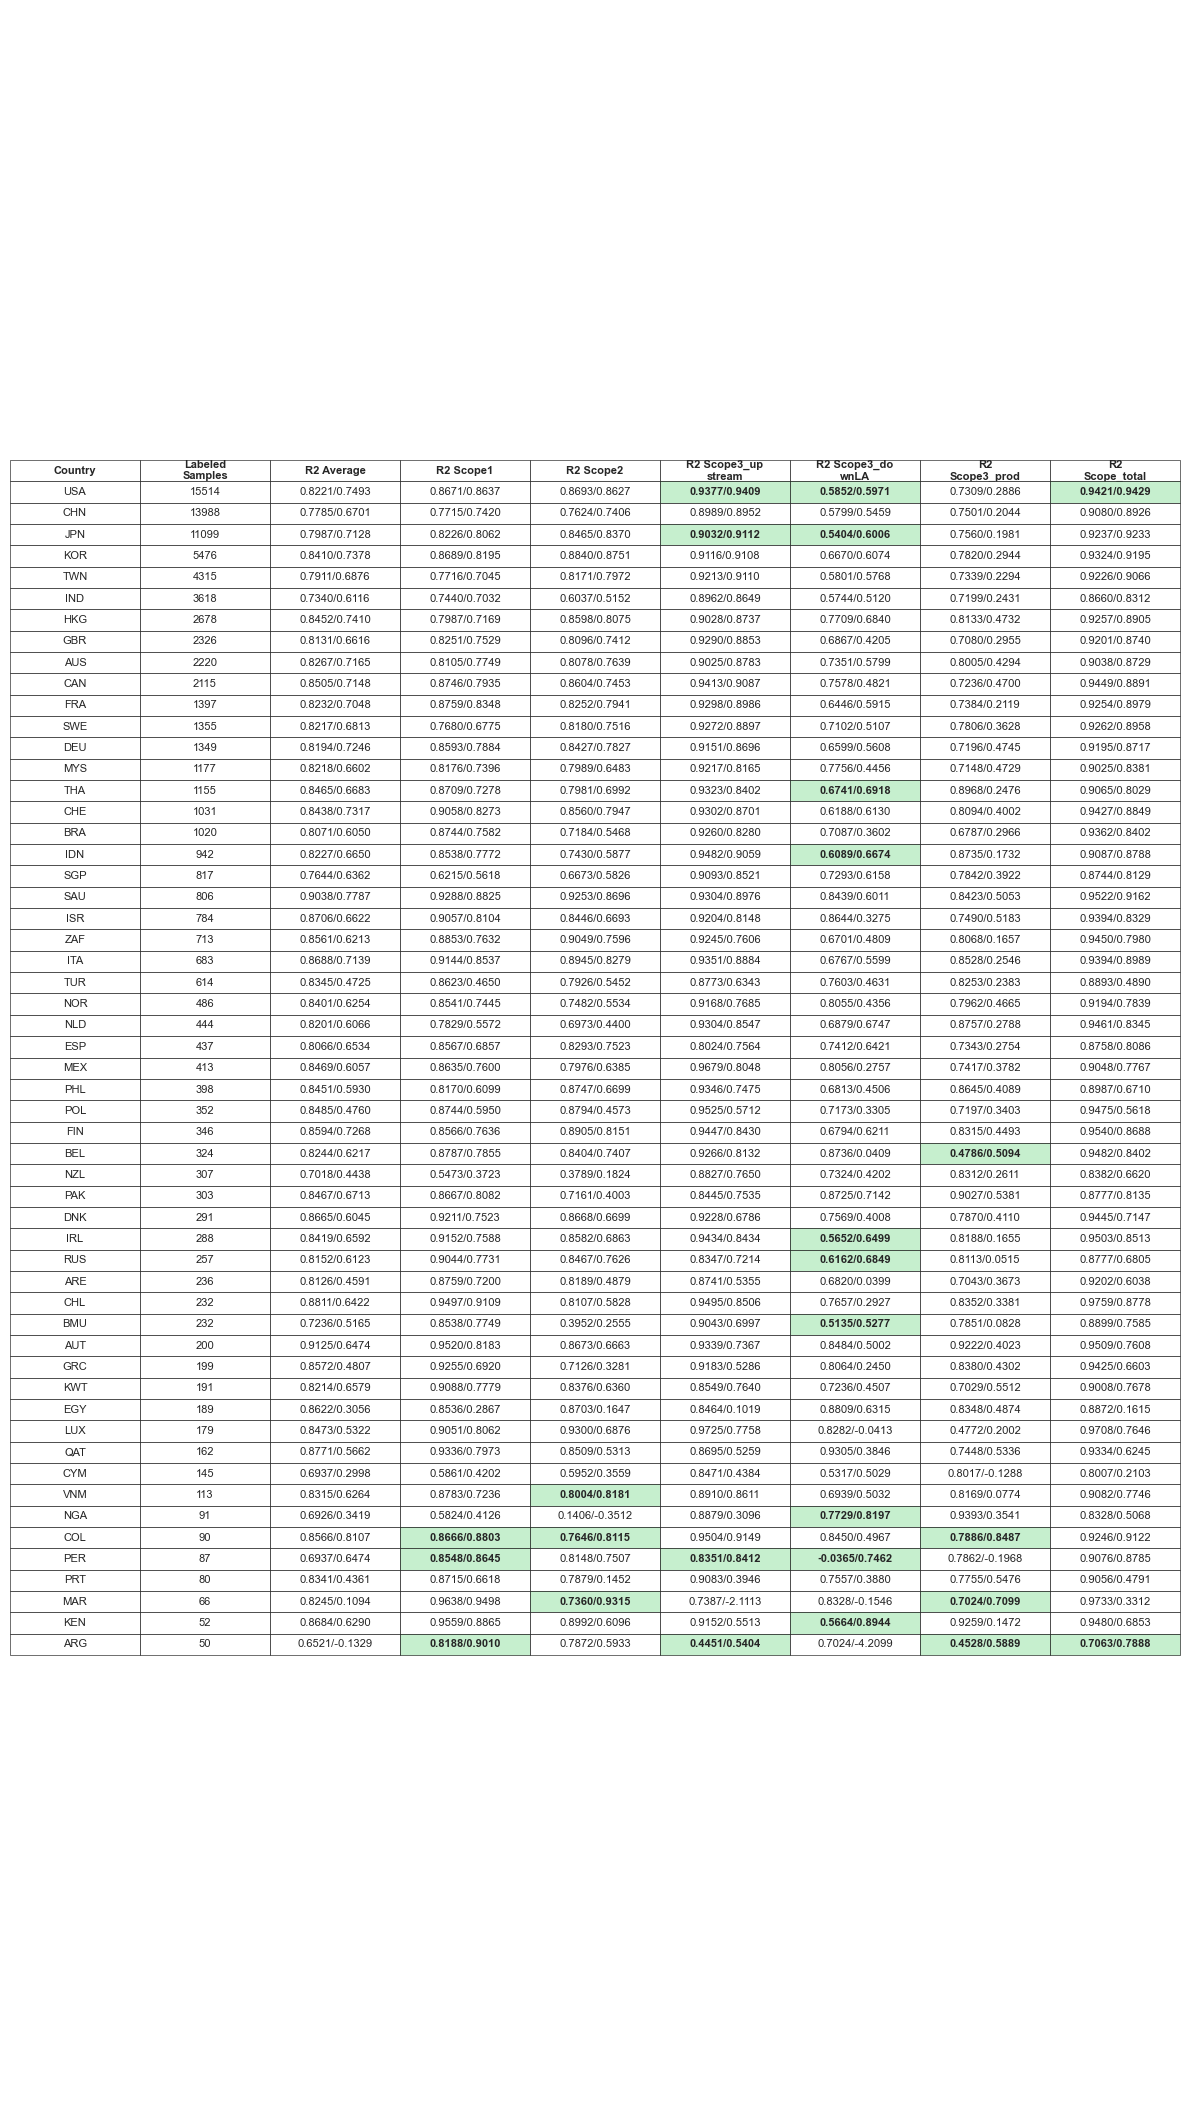

In [16]:
# Part 7) CT vs C comparison table (C/CT) with highlighting
metrics = ['R2_Average'] + [c for c in R2_COLS if c in ct_rows.columns]

# Build C and CT tables
c_rows = combined[combined['experiment_code'] == 'C'].copy()
ct_rows_comp = ct_rows.copy()

# Ensure R2 columns are numeric
for col in metrics:
    if col in c_rows.columns:
        c_rows[col] = pd.to_numeric(c_rows[col], errors='coerce')
    if col in ct_rows_comp.columns:
        ct_rows_comp[col] = pd.to_numeric(ct_rows_comp[col], errors='coerce')

# Labeled samples
def _label_count_from_country(country):
    return country_counts.get(country, np.nan)

c_rows['labeled_samples'] = c_rows['country'].apply(_label_count_from_country)
ct_rows_comp['labeled_samples'] = ct_rows_comp['country'].apply(_label_count_from_country)

# Keep one row per country
c_rows = c_rows.drop_duplicates(subset=['country'])
ct_rows_comp = ct_rows_comp.drop_duplicates(subset=['country'])

# Merge on country
comp = pd.merge(
    c_rows[['country','labeled_samples'] + metrics],
    ct_rows_comp[['country'] + metrics],
    on='country',
    how='inner',
    suffixes=('_C', '_CT')
)

# Sort by labeled samples desc
comp = comp.sort_values(by='labeled_samples', ascending=False, na_position='last')

# Build display table with C/CT format
display_cols = ['country', 'labeled_samples'] + metrics
display_df = pd.DataFrame()
display_df['country'] = comp['country']
display_df['labeled_samples'] = comp['labeled_samples']

for m in metrics:
    c_col = f"{m}_C"
    ct_col = f"{m}_CT"
    display_df[m] = [
        f"{c:.4f}/{ct:.4f}" if pd.notna(c) and pd.notna(ct) else ''
        for c, ct in zip(comp[c_col], comp[ct_col])
    ]

# Save CSV of raw values
raw_cols = ['country','labeled_samples'] + [f"{m}_C" for m in metrics] + [f"{m}_CT" for m in metrics]
raw_df = comp[raw_cols].copy()
raw_csv = os.path.join(results_dir, 'ct_vs_c_raw_values.csv')
raw_df.to_csv(raw_csv, index=False)
print('Saved CT vs C raw CSV:', raw_csv)

# Style: highlight cells where CT > C
def highlight_ct_better(val):
    try:
        c_str, ct_str = str(val).split('/')
        c_val = float(c_str)
        ct_val = float(ct_str)
        if ct_val > c_val:
            return 'background-color: #c6efce; font-weight: bold;'
    except Exception:
        pass
    return ''

styled = display_df.style.applymap(highlight_ct_better, subset=metrics).set_table_styles([
    {'selector': 'th', 'props': [('border', '1px solid black'), ('text-align', 'center'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('border', '1px solid black'), ('text-align', 'center')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]}
])

# Save PNG via matplotlib table (highlight cells)
header_map = {'country': 'Country', 'labeled_samples': 'Labeled Samples'}
for m in metrics:
    header_map[m] = m.replace('R2_log_', 'R2 ').replace('R2_', 'R2 ')

header_labels = ["\n".join(textwrap.wrap(header_map.get(c, c), width=12)) for c in display_df.columns]
fig_width = 12
fig_height = max(3, min(0.35 * len(display_df) + 2, 60))
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.axis('off')

tbl = ax.table(
    cellText=display_df.values,
    colLabels=header_labels,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.0)

# Bold header row
for j in range(len(display_df.columns)):
    cell = tbl[0, j]
    cell.set_text_props(weight='bold')

# Highlight CT better cells
for i in range(len(display_df)):
    for j, m in enumerate(metrics, start=2):
        val = display_df.iloc[i][m]
        try:
            c_str, ct_str = str(val).split('/')
            c_val = float(c_str)
            ct_val = float(ct_str)
            if ct_val > c_val:
                tbl[i+1, j].set_facecolor('#c6efce')
                tbl[i+1, j].set_text_props(weight='bold')
        except Exception:
            pass

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0.4)

plt.tight_layout()
ct_vs_c_png = os.path.join(results_dir, 'ct_vs_c_comparison_table.png')
plt.savefig(ct_vs_c_png, dpi=300, bbox_inches='tight')
print('Saved CT vs C comparison table image:', ct_vs_c_png)

styled

In [17]:
# Part 8) Emi-complete: best model per country/metric (including CT) + interpolation fill
metrics = ['R2_Average'] + [c for c in R2_COLS if c in ct_rows.columns]

# Build all-model results (A/B/C/D + CT)
all_models = combined.copy()
all_models['model_tag'] = all_models['experiment_code'].astype(str)
ct_all = ct_rows.copy()
ct_all['model_tag'] = ct_all.get('experiment_code', 'C_CT')
all_models = pd.concat([all_models, ct_all], ignore_index=True, sort=False)

# Ensure numeric
for m in metrics:
    if m in all_models.columns:
        all_models[m] = pd.to_numeric(all_models[m], errors='coerce')

# Add labeled samples for ordering
all_models['labeled_samples'] = all_models['country'].apply(lambda c: country_counts.get(c, np.nan))

# Best model per country per metric
best_rows = []
for country, sub in all_models.groupby('country'):
    row = {'country': country, 'labeled_samples': sub['labeled_samples'].iloc[0]}
    for m in metrics:
        if m not in sub.columns:
            row[f'best_model_{m}'] = ''
            row[f'best_r2_{m}'] = np.nan
            continue
        best_idx = sub[m].idxmax()
        best_val = sub.loc[best_idx, m]
        best_model = sub.loc[best_idx, 'model_tag'] if 'model_tag' in sub.columns else ''
        row[f'best_model_{m}'] = best_model
        row[f'best_r2_{m}'] = best_val
    best_rows.append(row)

emi_best = pd.DataFrame(best_rows)
emi_best = emi_best.sort_values(by='labeled_samples', ascending=False, na_position='last')

# Interpolate missing best_r2 values along labeled_samples order
emi_filled = emi_best.copy()
best_r2_cols = [c for c in emi_filled.columns if c.startswith('best_r2_')]
for col in best_r2_cols:
    emi_filled[col] = pd.to_numeric(emi_filled[col], errors='coerce')
    emi_filled[col] = emi_filled[col].interpolate(method='linear', limit_direction='both')

# Save outputs
emi_best_csv = os.path.join(results_dir, 'emi_complete_best_r2_raw.csv')
emi_filled_csv = os.path.join(results_dir, 'emi_complete_best_r2_filled.csv')
emi_best.to_csv(emi_best_csv, index=False)
emi_filled.to_csv(emi_filled_csv, index=False)
print('Saved Emi-complete raw best table:', emi_best_csv)
print('Saved Emi-complete interpolated table:', emi_filled_csv)

emi_filled.head()

Saved Emi-complete raw best table: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\emi_complete_best_r2_raw.csv
Saved Emi-complete interpolated table: d:\9_Projects\Transfer learning\Corporate_Carbon_Emissions_Transfer_Learning\results\emi_complete_best_r2_filled.csv


,country,labeled_samples,best_model_R2_Average,best_r2_R2_Average,best_model_R2_log_Scope1,best_r2_R2_log_Scope1,best_model_R2_log_Scope2,best_r2_R2_log_Scope2,best_model_R2_log_Scope3_upstream,best_r2_R2_log_Scope3_upstream,best_model_R2_log_Scope3_downLA,best_r2_R2_log_Scope3_downLA,best_model_R2_log_Scope3_prod,best_r2_R2_log_Scope3_prod,best_model_R2_log_Scope_total,best_r2_R2_log_Scope_total
52,USA,15514,A_star,0.904652,A_star,0.940338,A_star,0.945896,A_star,0.982471,A_star,0.733906,A_star,0.844063,A_star,0.981237
10,CHN,13988,A_star,0.882084,A_star,0.885432,A_star,0.871099,A_star,0.965517,A_star,0.784381,A_star,0.837264,A_star,0.948811
27,JPN,11099,A_star,0.876394,A_star,0.899197,A_star,0.915298,A_star,0.978153,A_star,0.695100,A_star,0.798389,A_star,0.972229
29,KOR,5476,A_star,0.877289,A_star,0.908394,A_star,0.946225,A_star,0.976656,A_star,0.682214,C_dev,0.793114,A_star,0.972898
51,TWN,4315,A_star,0.832302,A_star,0.833786,A_star,0.868193,A_star,0.972472,A_star,0.672109,C_dev,0.741941,A_star,0.942247
